# Genetic Algorithm (遺伝的アルゴリズム/進化アルゴリズム)

[genetic-algorithm | geeks for geeks](https://www.geeksforgeeks.org/dsa/genetic-algorithms/)

geeks for geeksのgenetic algorithmの記事を参考に簡単に実行してみる。
___
## 0.1 事前準備
この実行環境は`uv`を使用しています。

お手元の環境に`uv`をインストールして、次のステップに進んでください。

[Installation | uv](https://docs.astral.sh/uv/getting-started/installation/)

## 0.2 依存関係解消

`uv`を使用してライブラリをインストールしてください。

```bash
uv sync
```

## 0.3 venv activate

インストールしたら`uv venv`を実行し、venvの環境構築して起動してくださいください。

起動コマンド

win
```powershell
.\.venv\Scripts\activate
```

mac/linux

```bash
./.venv/bin/activate
```

## 0.4 起動
jupyter notebookのカーネルをga_sampleのpythonカーネルに割り当てたら完了
___

## 参考文献

- [genetic-algorithm | geeks for geeks](https://www.geeksforgeeks.org/dsa/genetic-algorithms/)
- [Stochastic universal sampling | wikipedia](https://en.wikipedia.org/wiki/Stochastic_universal_sampling)
- [最適化アルゴリズムを実装していくぞ（遺伝的アルゴリズム）@pocokhc(ちぃがぅ) | qiita](https://qiita.com/pocokhc/items/bca2b374b95c606e110f#%E3%83%AB%E3%83%BC%E3%83%AC%E3%83%83%E3%83%88%E6%96%B9%E5%BC%8F)

## 1 必要なライブラリのインポートとフィットネス関数の定義

今回使用するフィトネス関数の中身は
$ fitness\_function(x) = x \times \sin{10 \pi x}+1 $
のようです

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from abc import ABC


def fitness_function(x):
    return x * np.sin(10 * np.pi * x) + 1

## 2 パラメータ定義と母集団の初期化

In [ ]:
# 母集団の大きさ
POP_SIZE = 40
# 世代数
GENERATIONS = 100
# 変数が取りうる値
X_MIN, X_MAX = -1.0, 2.0
# 交叉する確率
CROSSOVER_PROB = 0.9
# 突然変異する確率
MUTATION_PROB = 0.2
# 突然変異の乱数に使用する正規分布の標準偏差
MUTATION_STD = 0.1

# 乱数初期化
np.random.seed(42)
# 母集団生成
population = np.random.uniform(X_MIN, X_MAX, POP_SIZE)

## 3 世代操作

※様々な手法を紹介するが実際には好きな手法を組み合わせる。

### 3.1 個体選択 (selection)
**a. ルーレット方式（Roulette Wheel Selection）**

各個体の選択が適応度（fitness score）によって選択される確率が正比例する方式。

1選出につき、1回ホイールを回す。

**b. トーナメント方式(Tournament Selection)**

ランダムに選出された小さな集団の中から、より適応度が高い個体が選択される方式。

**c. SUS方式 (確率的普遍サンプリング/Stochastic Universal Sampling)**

ルーレット方式とは違い、選出数回数ホイールを回すのとは違い、1つのホイールを選出回数で等分し選出するため、ルーレット方式で起こっていた偏りをなくすことができる。

In [3]:
# A. ルーレット方式
def roulette_wheel_selection(pop,fitness,k=3):
    selected=[]
    scores = np.fromiter(map(fitness,pop),dtype=float)
    weights = scores/np.sum(scores)
    idx = np.random.choice(len(pop),k,replace=True,p=weights)
    selected=[pop[i] for i in idx]
    return selected

# B. トーナメント方式
def tournament_selection(pop, fitness, k=3):
    selected = []
    for _ in range(len(pop)):
        idx = np.random.choice(len(pop), k, replace=False)
        selected.append(pop[idx[np.argmax(fitness[idx])]])
    return np.array(selected)

# SUS方式
def sus_selection(pop,fitness,k=3):
    scores = np.fromiter(map(fitness,pop),dtype=float)
    total_score=np.sum(scores)
    pointer_distance=total_score/k
    start_point=np.random.uniform(0,pointer_distance)
    pointers=start_point + np.arange(k)*pointer_distance
    cumsum_scores=np.cumsum(scores)
    idx = np.searchsorted(cumsum_scores,pointers)
    return [pop[i] for i in idx]

### 3.2 交叉 (crossover)

**a. Bit Flip Mutation**

**b. Swap Mutation**

**c. Scramble Mutation**

**d. Inversion Mutation**

In [4]:
def arithmetic_crossover(p1, p2):
    alpha = np.random.rand()
    return alpha * p1 + (1 - alpha) * p2, alpha * p2 + (1 - alpha) * p1

### 3.3 突然変異 (mutation)

In [5]:
def mutate(x):
    if np.random.rand() < MUTATION_PROB:
        x += np.random.normal(0, MUTATION_STD)
    return np.clip(x, X_MIN, X_MAX)

## 進化ループ

In [ ]:
best_history = []
mean_history = []
for _ in range(GENERATIONS):
    fitness = fitness_function(population)
    best_history.append(np.max(fitness))
    mean_history.append(np.mean(fitness))
    parents=sus_selection(population,fitness)
    # parents = tournament_selection(population, fitness)
    offspring = []
    np.random.shuffle(parents)
    for i in range(0, POP_SIZE, 2):
        if np.random.rand() < CROSSOVER_PROB:
            c1, c2 = arithmetic_crossover(parents[i], parents[i + 1])
        else:
            c1, c2 = parents[i], parents[i + 1]
        offspring.extend([mutate(c1), mutate(c2)])
    population = np.array(offspring)

TypeError: 'numpy.ndarray' object is not callable

: 

## 可視化

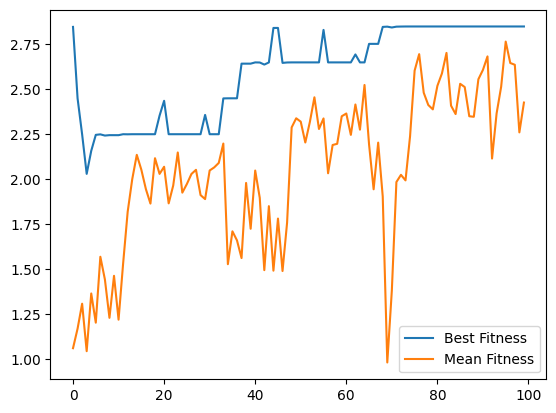

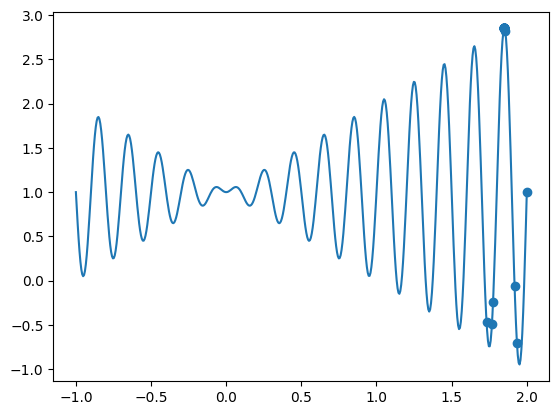

In [7]:
x = np.linspace(X_MIN, X_MAX, 500)

plt.figure()
plt.plot(best_history, label="Best Fitness")
plt.plot(mean_history, label="Mean Fitness")
plt.legend()
plt.show()

plt.figure()
plt.plot(x, fitness_function(x))
plt.scatter(population, fitness_function(population))
plt.show()